# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [282]:
#This is a regression problem where a target variable is used car price.

In [284]:
#With the historical data, I will work on feature selection and train the model to identify key columns that helps best with price prediction - for both higher price and lower price.

In [286]:
#I will be trying multiple Linear regression models to compare and find the best fit using MSE and MAE.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [289]:
#I will take a look at the column names and data types within the columns.

In [291]:
#I will filter out data where most of the features are missing as they won't help with anaylsis and can add unncessary noise.

In [293]:
#I will analyze total null values for each column.

In [295]:
#Id and VIN columns can be removed as they won't provide any information for prediction.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [405]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector, SelectFromModel
from sklearn import set_config
set_config(display="diagram")

In [300]:
#load the data in dataframe
df_cars = pd.read_csv('data/vehicles.csv')

In [302]:
df_cars.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [304]:
#show information about the columns
df_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [306]:
#drop rows where majority of the columns are null
df = df_cars.dropna(subset=['year','manufacturer','model','condition','cylinders','fuel','odometer','title_status','transmission','drive','size','type','paint_color'],how='all')

In [308]:
#check the data after dropping the null rows
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
27,7316814884,auburn,33590,2014.0,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,3GTP1VEC4EG551563,NaN,NaN,pickup,white,al
28,7316814758,auburn,22590,2010.0,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,1GCSCSE06AZ123805,NaN,NaN,pickup,blue,al
29,7316814989,auburn,39590,2020.0,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,3GCPWCED5LG130317,NaN,NaN,pickup,red,al
30,7316743432,auburn,30990,2017.0,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,5TFRM5F17HX120972,NaN,NaN,pickup,red,al
31,7316356412,auburn,15000,2013.0,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,NaN,rwd,full-size,truck,black,al


In [310]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 426812 entries, 27 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426812 non-null  int64  
 1   region        426812 non-null  object 
 2   price         426812 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426812 non-null  object 
dtypes: float

In [312]:
#As id and VIN columns are redudant in prediction analysis, drop those columns
df = df.drop(columns=['id','VIN'],errors='ignore' )
df.head()


,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
27,auburn,33590,2014.0,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,NaN,NaN,pickup,white,al
28,auburn,22590,2010.0,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,NaN,NaN,pickup,blue,al
29,auburn,39590,2020.0,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,NaN,NaN,pickup,red,al
30,auburn,30990,2017.0,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,NaN,NaN,pickup,red,al
31,auburn,15000,2013.0,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,full-size,truck,black,al


In [314]:
#show total null values in each column to understand what columns are reliable for analysis
df.isna().sum()

region               0
price                0
year              1137
manufacturer     17578
model             5209
condition       174036
cylinders       177610
fuel              2945
odometer          4332
title_status      8174
transmission      2488
drive           130499
size            306293
type             92790
paint_color     130135
state                0
dtype: int64

In [316]:
#Checking if region and state were representing same value pair and if one column is redundant 
region_to_state = df[['region','state']].drop_duplicates()
region_mismatches = region_to_state[region_to_state.duplicated(subset=['region'], keep=False)]
region_mismatches.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43 entries, 17134 to 416134
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   region  43 non-null     object
 1   state   43 non-null     object
dtypes: object(2)
memory usage: 1.0+ KB


In [318]:
#convert year from float to int
df['year'] = df['year'].astype('Int64')

In [320]:
#odometer is important information for predicting car value so drop rows where odometer value doesn't exist.
df.dropna(subset=['odometer'],inplace=True)

In [322]:
#Examine unique values for some non-numeric features. This helps select features to be used with get_dummies function
df['title_status'].unique()

array(['clean', 'rebuilt', 'lien', nan, 'salvage', 'missing',
       'parts only'], dtype=object)

In [324]:
df['fuel'].unique()

array(['gas', 'other', 'diesel', 'hybrid', nan, 'electric'], dtype=object)

In [326]:
df['region'].unique()

array(['auburn', 'birmingham', 'dothan', 'florence / muscle shoals',
       'gadsden-anniston', 'huntsville / decatur', 'mobile', 'montgomery',
       'tuscaloosa', 'anchorage / mat-su', 'fairbanks', 'kenai peninsula',
       'southeast alaska', 'flagstaff / sedona', 'mohave county',
       'phoenix', 'prescott', 'show low', 'sierra vista', 'tucson',
       'yuma', 'fayetteville', 'fort smith', 'jonesboro', 'little rock',
       'texarkana', 'bakersfield', 'chico', 'fresno / madera',
       'gold country', 'hanford-corcoran', 'humboldt county',
       'imperial county', 'inland empire', 'los angeles',
       'mendocino county', 'merced', 'modesto', 'monterey bay',
       'orange county', 'palm springs', 'redding', 'reno / tahoe',
       'sacramento', 'san diego', 'san luis obispo', 'santa barbara',
       'santa maria', 'SF bay area', 'siskiyou county', 'stockton',
       'susanville', 'ventura county', 'visalia-tulare', 'yuba-sutter',
       'boulder', 'colorado springs', 'denver', 'e

In [328]:
df['type'].unique()

array(['pickup', 'truck', 'other', nan, 'coupe', 'SUV', 'hatchback',
       'mini-van', 'sedan', 'offroad', 'bus', 'van', 'convertible',
       'wagon'], dtype=object)

In [330]:
df['transmission'].unique()

array(['other', 'automatic', 'manual', nan], dtype=object)

In [332]:
df['condition'].unique()

array(['good', 'excellent', 'fair', nan, 'like new', 'new', 'salvage'],
      dtype=object)

In [334]:
df['year'].unique

<bound method Series.unique of 27        2014
28        2010
29        2020
30        2017
31        2013
          ... 
426875    2019
426876    2020
426877    2020
426878    2018
426879    2019
Name: year, Length: 422480, dtype: Int64>

In [336]:
df['model'].unique

<bound method Series.unique of 27        sierra 1500 crew cab slt
28                  silverado 1500
29             silverado 1500 crew
30            tundra double cab sr
31                       f-150 xlt
                    ...           
426875           maxima s sedan 4d
426876    s60 t5 momentum sedan 4d
426877            xt4 sport suv 4d
426878             es 350 sedan 4d
426879    4 series 430i gran coupe
Name: model, Length: 422480, dtype: object>

In [338]:
df['manufacturer'].unique

<bound method Series.unique of 27              gmc
28        chevrolet
29        chevrolet
30           toyota
31             ford
            ...    
426875       nissan
426876        volvo
426877     cadillac
426878        lexus
426879          bmw
Name: manufacturer, Length: 422480, dtype: object>

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [341]:
#linreg1 = Linear Regression with 3 features: year,odometer and condition
df_clean = df.dropna(subset=['year','odometer','condition'], how='any')
X = pd.get_dummies(df_clean[['year','odometer','condition']])
y=df_clean['price']

X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
linreg1 = LinearRegression(fit_intercept=False).fit(X_train,y_train)
linreg1_mse= mean_squared_error(linreg1.predict(X_test),y_test)

linreg1_mse

24644326341121.383

In [347]:
#2: Liner Regression using fuel,year and odometer columns
df_clean = df.dropna(subset=['fuel','year', 'odometer'], how='any')
X = pd.get_dummies(df_clean[['fuel','year', 'odometer']])
y=df_clean['price']

X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
linreg2 = LinearRegression(fit_intercept=False).fit(X_train,y_train)
linreg2_mse= mean_squared_error(linreg2.predict(X_test),y_test)

linreg2_mse

167253509513278.4

In [349]:
#3: Liner Regression using fuel and odometer columns
df_clean = df.dropna(subset=['fuel', 'odometer'], how='any')
X = pd.get_dummies(df_clean[['fuel', 'odometer']])
y=df_clean['price']

X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
linreg3 = LinearRegression(fit_intercept=False).fit(X_train,y_train)
linreg3_mse= mean_squared_error(linreg3.predict(X_test),y_test)

linreg3_mse

368175586590123.44

In [351]:
#4: Liner Regression using fuel,year, transmission and odometer columns
df_clean = df.dropna(subset=['fuel','year', 'odometer', 'transmission'], how='any')
X = pd.get_dummies(df_clean[['fuel','year', 'odometer', 'transmission']])
y=df_clean['price']

X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
linreg4 = LinearRegression(fit_intercept=False).fit(X_train,y_train)
linreg4_mse= mean_squared_error(linreg4.predict(X_test),y_test)

linreg4_mse

518980748424.0555

In [353]:
#5: Liner Regression using fuel, year, odometer, transmission and type columns
df_clean = df.dropna(subset=['fuel','year', 'odometer', 'transmission', 'type'], how='any')
X = pd.get_dummies(df_clean[['fuel','year', 'odometer', 'transmission', 'type']])
y=df_clean['price']

X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
linreg5 = LinearRegression(fit_intercept=False).fit(X_train,y_train)
linreg5_mse= mean_squared_error(linreg5.predict(X_test),y_test)

linreg5_mse

30481135202627.145

In [355]:
#6: Liner Regression using fuel,year, odometer, transmission and condition columns
df_clean = df.dropna(subset=['fuel','year', 'odometer', 'transmission', 'condition'], how='any')
X = pd.get_dummies(df_clean[['fuel','year', 'odometer', 'transmission', 'condition']])
y=df_clean['price']

X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
linreg6 = LinearRegression(fit_intercept=False).fit(X_train,y_train)
linreg6_mse= mean_squared_error(linreg6.predict(X_test),y_test)

linreg6_mse

24640037611840.156

In [357]:
#7: Liner Regression using fuel,year, odometer, transmission, condition and type columns
df_clean = df.dropna(subset=['fuel','year', 'odometer', 'transmission', 'condition', 'type'], how='any')
X = pd.get_dummies(df_clean[['fuel','year', 'odometer', 'transmission', 'condition', 'type']])
y=df_clean['price']

X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
linreg7 = LinearRegression(fit_intercept=False).fit(X_train,y_train)
linreg7_mse= mean_squared_error(linreg7.predict(X_test),y_test)

linreg7_mse

15758888812.224579

In [359]:
#8: Liner Regression using fuel,year, odometer, transmission, condition, type and manufacturer columns
df_clean = df.dropna(subset=['fuel','year', 'odometer', 'transmission', 'condition', 'type', 'manufacturer'], how='any')
X = pd.get_dummies(df_clean[['fuel','year', 'odometer', 'transmission', 'condition', 'type', 'manufacturer']])
y=df_clean['price']

X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
linreg8 = LinearRegression(fit_intercept=False).fit(X_train,y_train)
linreg8_mse= mean_squared_error(linreg8.predict(X_test),y_test)

linreg8_mse

460446621076.787

In [361]:
#9: Liner Regression using fuel,year, odometer, transmission, condition, type, manufacturer and drive columns
df_clean = df.dropna(subset=['fuel','year', 'odometer', 'transmission', 'condition', 'type', 'manufacturer','drive'], how='any')
X = pd.get_dummies(df_clean[['fuel','year', 'odometer', 'transmission', 'condition', 'type', 'manufacturer','drive']])
y=df_clean['price']

X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
linreg9 = LinearRegression(fit_intercept=False).fit(X_train,y_train)
linreg9_mse= mean_squared_error(linreg9.predict(X_test),y_test)

linreg9_mse

506531063323.10864

In [363]:
#Find which model has lowest mse
mses = (linreg1_mse, linreg2_mse, linreg3_mse, linreg4_mse, linreg5_mse, linreg6_mse, linreg6_mse, linreg7_mse, linreg8_mse, linreg9_mse)
X = mses.index(min(mses))
print(mses[X])


15758888812.224579


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [368]:
#find co-efficients from model 7 as it has lowest mean squared error on test data
df_clean = df.dropna(subset=['fuel','year', 'odometer', 'transmission', 'condition', 'type'], how='any')
X = pd.get_dummies(df_clean[['fuel','year', 'odometer', 'transmission', 'condition', 'type']])
y=df_clean['price']
X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
coeffs = pd.DataFrame({'Feature':X_train.columns, 'Coefficients':linreg7.coef_})
coeffs

,Feature,Coefficients
0,year,-1.637639e+03
1,odometer,4.068794e-02
2,fuel_diesel,9.321370e+05
3,fuel_electric,8.592385e+05
4,fuel_gas,8.259532e+05
5,fuel_hybrid,8.174528e+05
6,fuel_other,8.174990e+05
7,transmission_automatic,1.454615e+06
8,transmission_manual,1.388243e+06
9,transmission_other,1.409423e+06


In [370]:
#The coefficients look counterintuitive: 
#where I was expecting to see positive coefficient, it has negative (for year)  
#where I was expecting higher values, it has value similar to other values of same feature (condition_like new)
#where I was expecting negative values or very small values, it has comparatively higher values (odometer)
#I will make an attempt to find out the reason

In [372]:
#10: Unique values for 'year' was showing correct format values but building model just on a year to check the coefficient
df_clean = df.dropna(subset=['year'], how='any')
X = df_clean[['year']]
y=df_clean['price']

X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
linreg10 = LinearRegression(fit_intercept=False).fit(X_train,y_train)
linreg10_mse= mean_squared_error(linreg10.predict(X_test),y_test)
print(linreg10_mse)
print(linreg10.coef_)

23780752904223.61
[42.59585049]


In [374]:
#This looks good - the coefficient is showing 42 meaning increase in each year increases the price by $42 (considering no other factors for a moment) - this means values in 'year' column is not an issue so does this mean there is an issue with combination of features I have used?

In [376]:
#Type and Transmission look similar so possible the higher multivariate coefficients are causing the issue. Type has more defined values so keeping 'type' here and removing 'transmission'. 
#11: Liner Regression using fuel, odometer, condition and type columns. 
df_clean = df.dropna(subset=['fuel', 'year', 'odometer',  'condition', 'type'], how='any')
X = pd.get_dummies(df_clean[['fuel', 'year', 'odometer', 'condition', 'type']])
y=df_clean['price']

X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
linreg11 = LinearRegression(fit_intercept=False).fit(X_train,y_train)
linreg11_mse= mean_squared_error(linreg11.predict(X_test),y_test)
coeffs = pd.DataFrame({'Feature':X_train.columns, 'Coefficients':linreg11.coef_})
print(f'Mean Squared Error for linreg11 is : {linreg11_mse}')
print(f'Coefficients for linreg11 is :  {coeffs}')

Mean Squared Error for linreg11 is : 19988059441.181347
Coefficients for linreg11 is :                  Feature  Coefficients
0                  year -1.782288e+03
1              odometer  4.600360e-02
2           fuel_diesel  1.716783e+06
3         fuel_electric  1.631848e+06
4              fuel_gas  1.608355e+06
5           fuel_hybrid  1.602189e+06
6            fuel_other  1.589415e+06
7   condition_excellent  1.400925e+06
8        condition_fair  1.326860e+06
9        condition_good  1.352376e+06
10   condition_like new  1.388968e+06
11        condition_new  1.366441e+06
12    condition_salvage  1.313021e+06
13             type_SUV  6.075877e+05
14             type_bus  5.647481e+05
15     type_convertible  5.962311e+05
16           type_coupe  6.204944e+05
17       type_hatchback  6.295328e+05
18        type_mini-van  5.953319e+05
19         type_offroad  5.842401e+05
20           type_other  6.551227e+05
21          type_pickup  8.654412e+05
22           type_sedan  6.177351e+05


In [378]:
#Somehow the coefficient for year is still negative and other coefficients look flat across the values (For fuel, condition) meaning they are not providing meaning information.
#Researching gave a clue that some feature might be highli correlated with one another. Looking at data again, year and mileage might be one of them so trying to remove 'year' as mileage has more granular information/values so keeping mileage.

In [401]:
#Type and Transmission look similar so possible the higher multivariate coefficients are causing the issue. Type has more defined values so keeping 'type' here and removing 'transmission'. 
#12: Liner Regression using fuel, odometer, condition and type columns. 
df_clean = df.dropna(subset=['fuel', 'odometer',  'condition', 'type'], how='any')
X = pd.get_dummies(df_clean[['fuel', 'odometer', 'condition', 'type']])
y=df_clean['price']

X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
linreg12 = LinearRegression(fit_intercept=False).fit(X_train,y_train)
linreg12_mse= mean_squared_error(linreg12.predict(X_test),y_test)
coeffs = pd.DataFrame({'Feature':X_train.columns, 'Coefficients':linreg12.coef_})
print(f'Mean Squared Error for linreg12 is : {linreg12_mse}')
print(f'Coefficients for linreg12 is :  {coeffs}')

Mean Squared Error for linreg12 is : 19584039813.734795
Coefficients for linreg12 is :                  Feature   Coefficients
0              odometer       0.057288
1           fuel_diesel  106221.690727
2         fuel_electric   15298.591151
3              fuel_gas   -2441.731519
4           fuel_hybrid  -11681.257117
5            fuel_other  -28928.538210
6   condition_excellent   51204.366327
7        condition_fair   -2347.112398
8        condition_good     950.898013
9    condition_like new   36787.671961
10        condition_new   12547.809305
11    condition_salvage  -20674.878174
12             type_SUV  -17779.606421
13             type_bus  -51196.082575
14     type_convertible   -9699.415870
15           type_coupe    4104.737733
16       type_hatchback    2402.600564
17        type_mini-van  -27649.275897
18         type_offroad  -22172.658119
19           type_other   26689.025399
20          type_pickup  240618.518649
21           type_sedan   -7041.806096
22           ty

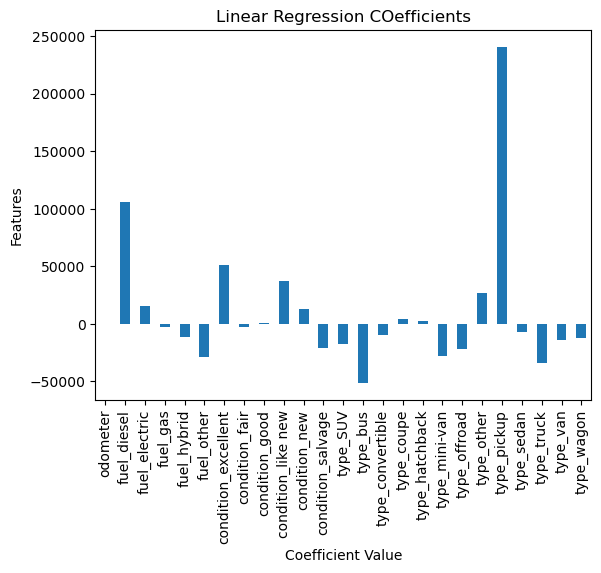

In [417]:
#The coefficients look reasonable for most of the feature values. As the highly correlated features are removed now, adding a graphical representation of co-efficients to help with recommendations.
coef_series = pd.Series(linreg12.coef_,index=X_train.columns)

coef_series.plot(kind="bar")
plt.title("Linear Regression COefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()

In [419]:
#I want to try adding manufacturer before I start interpreting the coefficients from linreg12.
#13: Liner Regression using fuel, odometer, condition, manufacturer and type columns
df_clean = df.dropna(subset=['fuel', 'odometer',  'condition', 'manufacturer', 'type'], how='any')
X = pd.get_dummies(df_clean[['fuel', 'odometer', 'condition', 'manufacturer', 'type']])
y=df_clean['price']

X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
linreg13 = LinearRegression(fit_intercept=False).fit(X_train,y_train)
linreg13_mse= mean_squared_error(linreg13.predict(X_test),y_test)
coeffs = pd.DataFrame({'Feature':X_train.columns, 'Coefficients':linreg13.coef_})
print(f'Mean Squared Error for linreg13 is : {linreg13_mse}')
print(f'Coefficients for linreg13 is :  {coeffs}')

Mean Squared Error for linreg13 is : 332598406190294.1
Coefficients for linreg13 is :            Feature   Coefficients
0        odometer      -0.002740
1     fuel_diesel  159654.063870
2   fuel_electric  -14798.679624
3        fuel_gas  -10265.584456
4     fuel_hybrid   -8461.622682
..            ...            ...
62    type_pickup   67360.486347
63     type_sedan    9347.610033
64     type_truck  -11743.169976
65       type_van    3676.561758
66     type_wagon    1602.204321

[67 rows x 2 columns]


In [420]:
#The mse for linreg13 is much higher than linreg12 so I will go with linreg12 as the mse is the lowest and coefficients look mostly reasonable.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In [389]:
#From given historical data for used car sales, a linear regression model was developed using fuel, odometer, condition and type.

In [391]:
#1. Fuel Type Significantly Impacts Vehicle Value
#Diesel vehicles showed the strongest positive association with price.
#Electric vehicles also commanded a price premium, though substantially smaller than diesel vehicles.
#Hybrid, Other, and Gas-powered vehicles generally showed lower pricing impact relative to the baseline category.

In [393]:
#2. Vehicle Condition Is a Major Value Driver
#Vehicles in excellent condition showed a substantially higher expected selling price and then like new, new, good and fair in order. fair seems to make the price go down.

In [395]:
#3. Type of the car: 'pickup' trucks has significant effect on pricing. This shows some relation with higher car prices for diesel fuel type vehnicles.
# sedan, van, wagon moderately impact the price while 'truck' and 'bus' type would make the price lower.

In [397]:
#4. Even though odometer has a very small positive coefficient but it should not be interepreted that higher mileage increases ehicle value. Additional analysis including other features show negative coefficient meaning the increasing mileage value makes the car price go down.

In [399]:
#High level recommendation to dealers:
#Prioritize acquisitions of pick up trucks, diesel vehicles, electric vehicle and vehicles in excellent or like-new condition.
#Take caution with Salvage cars and type 'truck'.